In [1]:
# import libraries

import pandas as pd
import json

In [2]:
# Load Dataset

orders = pd.read_csv("data/orders.csv")
order_items = pd.read_csv("data/order_items.csv")
products = pd.read_csv("data/products.csv")

In [3]:
# Create Revenue Column

order_items["revenue"] = order_items["quantity"] * order_items["price_at_purchase"]

order_items.head()

,order_item_id,order_id,product_id,quantity,price_at_purchase,item_status,rand_val,revenue
0,1,1,167,3,3452.41,Returned,0.008142,10357.23
1,2,1,70,1,2372.78,Returned,0.045928,2372.78
2,3,2,87,2,7499.93,Returned,0.205213,14999.86
3,4,2,26,2,1825.30,Completed,0.888281,3650.60
4,5,2,118,2,4610.05,Completed,0.825768,9220.10


In [7]:
# Merge Tables

# order_items with orders
sales = order_items.merge(orders, on="order_id",how="left")

# with products
sales = sales.merge(products, on="product_id", how="left")

sales.head()

,order_item_id,order_id,product_id,quantity,price_at_purchase,item_status,rand_val,revenue,customer_id,order_date,order_status,payment_method,product_name,category,sub_category,gender,price,weight_bucket
0,1,1,167,3,3452.41,Returned,0.008142,10357.23,1,2025-05-21,Completed,UPI,Product_167,Footwear,Sneakers,Unisex,3658.41,NaN
1,2,1,70,1,2372.78,Returned,0.045928,2372.78,1,2025-05-21,Completed,UPI,Product_70,Apparel,T-Shirts,Women,2483.47,NaN
2,3,2,87,2,7499.93,Returned,0.205213,14999.86,1,2025-03-22,Completed,UPI,Product_87,Footwear,Sneakers,Unisex,7620.99,NaN
3,4,2,26,2,1825.30,Completed,0.888281,3650.60,1,2025-03-22,Completed,UPI,Product_26,Apparel,T-Shirts,Men,1902.77,NaN
4,5,2,118,2,4610.05,Completed,0.825768,9220.10,1,2025-03-22,Completed,UPI,Product_118,Footwear,Sneakers,Men,5037.64,NaN


In [9]:
# Convert Date Column

sales["order_date"] = pd.to_datetime(sales["order_date"])

sales["year"] = sales["order_date"].dt.year
sales["month"] = sales["order_date"].dt.to_period("M")

In [10]:
monthly_revenue = (
    sales[sales["item_status"] == "Completed"]
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,month,revenue
0,2024-01,323530.05
1,2024-02,762268.14
2,2024-03,1157360.68
3,2024-04,1678642.59
4,2024-05,1961958.01


## Calculate Z-Score 

In [11]:
# Z-score measures how far a value is from the average

import numpy as np

monthly_revenue["z_score"] = (
                monthly_revenue["revenue"] - monthly_revenue["revenue"].mean()
           ) / monthly_revenue["revenue"].std()

monthly_revenue.head()

,month,revenue,z_score
0,2024-01,323530.05,-1.564713
1,2024-02,762268.14,-1.332456
2,2024-03,1157360.68,-1.123303
3,2024-04,1678642.59,-0.847348
4,2024-05,1961958.01,-0.697368


In [17]:
# Flag Anomalies

monthly_revenue["anomaly"] = monthly_revenue["z_score"].abs() > 1.5

monthly_revenue

,month,revenue,z_score,anomaly
0,2024-01,323530.05,-1.564713,True
1,2024-02,762268.14,-1.332456,False
2,2024-03,1157360.68,-1.123303,False
3,2024-04,1678642.59,-0.847348,False
4,2024-05,1961958.01,-0.697368,False
5,2024-06,2128968.63,-0.608956,False
6,2024-07,2907877.18,-0.196620,False
7,2024-08,2916972.74,-0.191805,False
8,2024-09,3325151.61,0.024275,False
9,2024-10,4318618.41,0.550194,False


In [18]:
# Extract Anomalous Months

anomalies = monthly_revenue[monthly_revenue["anomaly"]]

anomalies

,month,revenue,z_score,anomaly
0,2024-01,323530.05,-1.564713,True
11,2024-12,6465332.60,1.686614,True
12,2025-01,6739021.46,1.831499,True
23,2025-12,345022.21,-1.553336,True


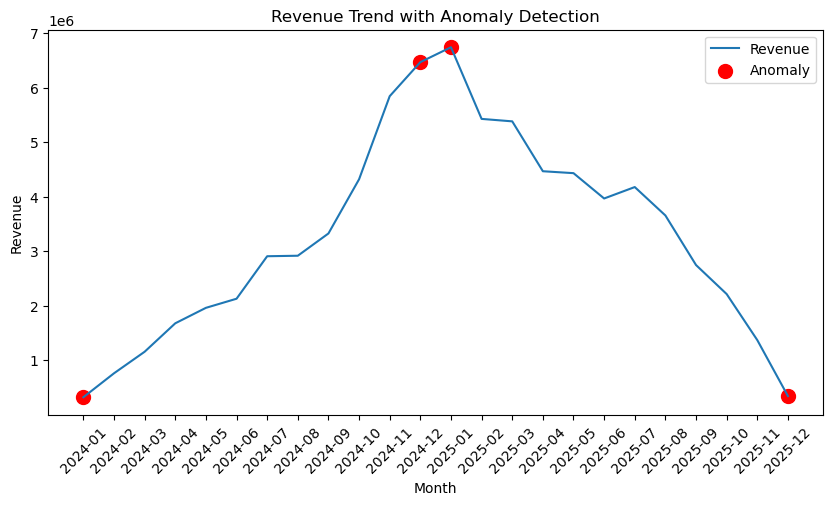

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_revenue["month"].astype(str), monthly_revenue["revenue"], label="Revenue")

plt.scatter(
    anomalies["month"].astype(str),
    anomalies["revenue"],
    color="red",
    label="Anomaly",
    s=100
)

plt.title("Revenue Trend with Anomaly Detection")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.legend()

plt.show()

In [21]:
anomalies = monthly_revenue[monthly_revenue["anomaly"]]

if len(anomalies) > 0:
    print("Anomalous revenue periods detected:")

    for _, row in anomalies.iterrows():
        print(f"Month {row['month']} shows unusual revenue behavior.")

else:
    print("No major anomalies detected in revenue trends.")

Anomalous revenue periods detected:
Month 2024-01 shows unusual revenue behavior.
Month 2024-12 shows unusual revenue behavior.
Month 2025-01 shows unusual revenue behavior.
Month 2025-12 shows unusual revenue behavior.
